# 05 — Forecasting Refinement & Demand Proxy
**Day 4.** Goal: (1) add a demand-forecasting target, (2) tune the Day 3 generation model to
address the seasonal bias found in error analysis, (3) run deeper error analysis, (4) write the
one-page model summary for the proposal appendix.

**On demand data — read before running:** none of the 12 provided datasets contain load/consumption
data (confirmed Day 1). Per the work plan's own fallback instruction, this notebook builds a
**documented synthetic proxy** using ambient temperature (cooling-load driven, since this site's
temperature range of 23–31°C is tropical, not the heating-driven U-shape you'd see in a temperate
climate) plus a weekday/weekend multiplier. **This is clearly labeled everywhere it's used — the
dashboard and copilot must say "proxy" or "simulated," never imply it's real grid load.**

In [29]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config_loader import load_config, processed_path
from src.features.demand_proxy import generate_demand_proxy
from src.features.time_features import add_daily_lag_and_target
from src.models.forecasting_model_utils import chronological_split, regression_metrics, save_model, load_model
from src.models.tuning import chronological_grid_search

cfg = load_config()

try:
    import xgboost as xgb
    MODEL_BACKEND = "xgboost"
    print("Using XGBoost")
except ImportError:
    from sklearn.ensemble import HistGradientBoostingRegressor
    MODEL_BACKEND = "sklearn_fallback"
    print("XGBoost not found -- falling back to sklearn. Run: pip install -r requirements.txt")


Using XGBoost


## Part A — Demand Forecasting Proxy

In [30]:
daily = pd.read_csv(processed_path("daily_generation_features.csv", cfg), parse_dates=["timestamp"])
print("Loaded Day 3 feature table:", daily.shape)
daily.head()
daily["demand_proxy_kwh"] = generate_demand_proxy(daily, temp_col="mean_ambient_temp", day_of_week_col="day_of_week")
daily["demand_proxy_kwh"].describe()



Loaded Day 3 feature table: (334, 21)


count      334.000000
mean     21602.287930
std       3241.023223
min      15057.709111
25%      19178.037703
50%      21041.087105
75%      24774.813417
max      27900.416416
Name: demand_proxy_kwh, dtype: float64

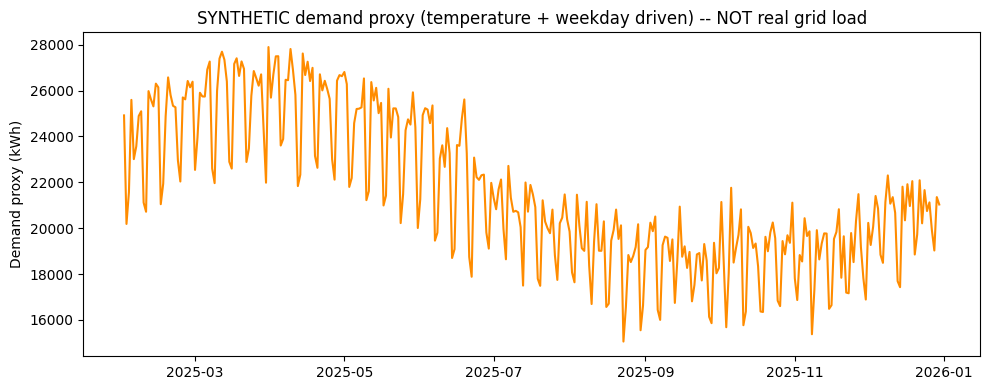

In [31]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily["timestamp"], daily["demand_proxy_kwh"], color="darkorange")
ax.set_ylabel("Demand proxy (kWh)")
ax.set_title("SYNTHETIC demand proxy (temperature + weekday driven) -- NOT real grid load")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports/figures/day4_demand_proxy.png", dpi=150)
plt.show()


### Build lag features and target for the demand model
Same leakage-safe pattern as the generation model: lags/rolling means are shifted to only use past information.

In [32]:
daily["demand_lag_1d"] = daily["demand_proxy_kwh"].shift(1)
daily["demand_lag_7d"] = daily["demand_proxy_kwh"].shift(7)
daily["demand_rolling_mean_7d"] = daily["demand_proxy_kwh"].shift(1).rolling(7).mean()
daily["target_next_1day_demand_kwh"] = daily["demand_proxy_kwh"].shift(-1)

demand_model_df = daily.dropna().reset_index(drop=True)
print("Rows:", len(demand_model_df))


Rows: 326


In [33]:
demand_target_col = "target_next_1day_demand_kwh"
generation_target_col = "target_next_1day_generation_kwh"
exclude_cols = ["timestamp", "generation_kwh", "demand_proxy_kwh", demand_target_col, generation_target_col]
demand_feature_cols = [c for c in demand_model_df.columns if c not in exclude_cols]

train_d, val_d, test_d = chronological_split(demand_model_df,
                                              cfg["modeling"]["chronological_split"]["train"],
                                              cfg["modeling"]["chronological_split"]["val"])

if MODEL_BACKEND == "xgboost":
    demand_model = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
else:
    demand_model = HistGradientBoostingRegressor(random_state=42)

demand_model.fit(train_d[demand_feature_cols], train_d[demand_target_col])
pred_demand_test = demand_model.predict(test_d[demand_feature_cols])
demand_metrics = regression_metrics(test_d[demand_target_col], pred_demand_test)
print("Demand proxy model -- test metrics:", demand_metrics)


Demand proxy model -- test metrics: {'MAE': 842.0182841949529, 'RMSE': 1074.4637520314552, 'MAPE': 4.170431887398529}


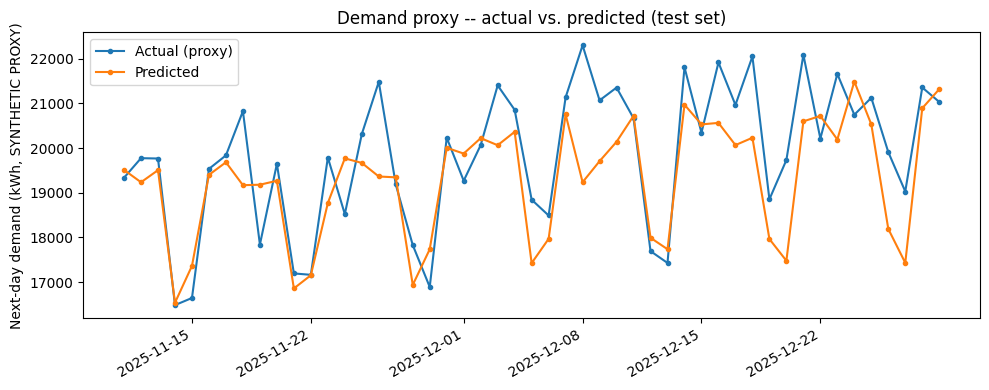

In [34]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test_d["timestamp"], test_d[demand_target_col], label="Actual (proxy)", marker="o", markersize=3)
ax.plot(test_d["timestamp"], pred_demand_test, label="Predicted", marker="o", markersize=3)
ax.set_ylabel("Next-day demand (kWh, SYNTHETIC PROXY)")
ax.set_title("Demand proxy -- actual vs. predicted (test set)")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports/figures/day4_demand_actual_vs_predicted.png", dpi=150)
plt.show()


In [35]:
model_path = PROJECT_ROOT / "models" / "next_day_demand_proxy_model.joblib"
save_model(demand_model, model_path, metadata={
    "backend": MODEL_BACKEND,
    "feature_cols": demand_feature_cols,
    "target_col": demand_target_col,
    "test_metrics": demand_metrics,
    "IS_SYNTHETIC_PROXY": True,
    "proxy_method": "temperature-driven cooling load + weekday multiplier, see src/features/demand_proxy.py",
})
print("Saved:", model_path)


Saved: c:\Users\ashok\Downloads\wind-energy-ai-platform\wind-energy-ai-platform\models\next_day_demand_proxy_model.joblib


## Part B — Tuning the Generation Model

**Recap of Day 3's finding:** the baseline model underpredicted the test period (Nov–Dec) by
~1,140 kWh/day on average. Investigating why, monthly generation actually bottoms out in
Sep–Oct (~11,000 kWh/day) then *rises* again through Nov–Dec (~12,600 → ~15,600 kWh/day) as
winter wind picks up. Training data ends Sep 20 — right near that trough — so the model never
saw a prior winter's recovery pattern and under-shoots it. **This is a data-coverage limitation
(only 1 year of history), not something a smarter model architecture fixes on its own.** Worth
tuning anyway to see how much headroom exists, but the honest fix is more historical data.

In [36]:
train, val, test = chronological_split(daily.dropna(subset=[generation_target_col] + 
    [c for c in daily.columns if "gen_" in c or "wind_rolling" in c]).reset_index(drop=True),
    cfg["modeling"]["chronological_split"]["train"], cfg["modeling"]["chronological_split"]["val"])

gen_feature_cols = [c for c in train.columns if c not in
                    ["timestamp", "generation_kwh", generation_target_col, "demand_proxy_kwh",
                     "demand_lag_1d", "demand_lag_7d", "demand_rolling_mean_7d", demand_target_col]]

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")


Train: 233, Val: 50, Test: 51


In [37]:
if MODEL_BACKEND == "xgboost":
    param_grid = {
        "n_estimators": [200, 400],
        "max_depth": [3, 4, 6],
        "learning_rate": [0.03, 0.05, 0.1],
    }
    model_factory = lambda **p: xgb.XGBRegressor(random_state=42, subsample=0.8, colsample_bytree=0.8, **p)
else:
    param_grid = {
        "max_iter": [100, 300],
        "learning_rate": [0.03, 0.1],
        "max_depth": [3, 5, None],
    }
    model_factory = lambda **p: HistGradientBoostingRegressor(random_state=42, **p)

best_params, search_results = chronological_grid_search(
    model_factory, param_grid,
    train[gen_feature_cols], train[generation_target_col],
    val[gen_feature_cols], val[generation_target_col],
)
print("Best params (by validation MAE):", best_params)
search_results.head(10)


Best params (by validation MAE): {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03}


,n_estimators,max_depth,learning_rate,val_MAE,val_RMSE
0,200,3,0.03,771.766145,943.223428
1,400,3,0.03,781.490793,939.674733
2,200,3,0.05,784.305179,950.648511
3,200,4,0.03,820.453380,992.290651
4,200,6,0.03,832.248726,1004.067341
5,400,6,0.03,841.061302,1001.526843
6,400,3,0.05,844.609638,1002.517913
7,400,4,0.03,846.507327,999.605361
8,200,3,0.1,868.153819,1031.065041
9,200,4,0.1,873.776397,1012.709313


### Retrain on train+val with the best params, evaluate on the untouched test set

In [38]:
trainval = pd.concat([train, val]).reset_index(drop=True)
tuned_model = model_factory(**best_params)
tuned_model.fit(trainval[gen_feature_cols], trainval[generation_target_col])
pred_tuned = tuned_model.predict(test[gen_feature_cols])
tuned_metrics = regression_metrics(test[generation_target_col], pred_tuned)

# Reload Day 3's baseline for a fair side-by-side (same test set)
baseline_model, baseline_meta = load_model(PROJECT_ROOT / "models" / "next_day_generation_model.joblib")
baseline_metrics = baseline_meta["test_metrics"]

comparison = pd.DataFrame([baseline_metrics, tuned_metrics], index=["Day 3 baseline", "Day 4 tuned"])
comparison


,MAE,RMSE,MAPE
Day 3 baseline,1363.431612,1658.123365,8.987581
Day 4 tuned,991.605140,1367.959240,6.477731


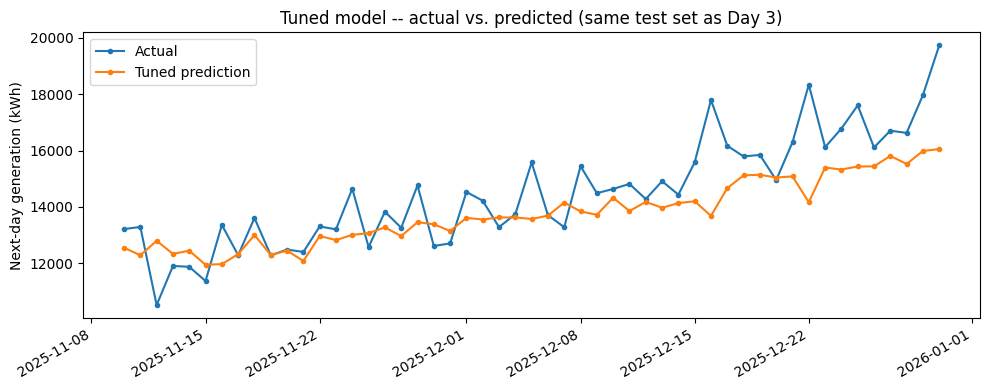

In [39]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test["timestamp"], test[generation_target_col], label="Actual", marker="o", markersize=3)
ax.plot(test["timestamp"], pred_tuned, label="Tuned prediction", marker="o", markersize=3)
ax.set_ylabel("Next-day generation (kWh)")
ax.set_title("Tuned model -- actual vs. predicted (same test set as Day 3)")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports/figures/day4_tuned_actual_vs_predicted.png", dpi=150)
plt.show()


## Part C — Deeper Error Analysis

In [40]:
test_analysis = test.copy()
test_analysis["predicted"] = pred_tuned
test_analysis["residual"] = test_analysis[generation_target_col] - test_analysis["predicted"]
test_analysis["month"] = test_analysis["timestamp"].dt.month

monthly_error = test_analysis.groupby("month")[[generation_target_col, "predicted", "residual"]].mean()
monthly_error


,target_next_1day_generation_kwh,predicted,residual
month,,,
11,12835.830952,12696.718750,139.112667
12,15660.320000,14533.008789,1127.311178


In [41]:
print(f"Residual mean (bias): {test_analysis['residual'].mean():,.1f} kWh  (Day 3 baseline was ~1,140)")
print(f"Residual std (spread): {test_analysis['residual'].std():,.1f} kWh")

low_wind = test_analysis[test_analysis["mean_wind_speed"] < test_analysis["mean_wind_speed"].median()]
high_wind = test_analysis[test_analysis["mean_wind_speed"] >= test_analysis["mean_wind_speed"].median()]
print(f"Mean abs error, low-wind days:  {low_wind['residual'].abs().mean():,.1f} kWh")
print(f"Mean abs error, high-wind days: {high_wind['residual'].abs().mean():,.1f} kWh")


Residual mean (bias): 720.4 kWh  (Day 3 baseline was ~1,140)
Residual std (spread): 1,174.5 kWh
Mean abs error, low-wind days:  734.0 kWh
Mean abs error, high-wind days: 1,239.3 kWh


## Part D — Save the tuned model and write the Day 4 one-pager
The summary is generated from this run's actual numbers, not hand-typed, so it can't drift from what the notebook produced.

In [42]:
tuned_model_path = PROJECT_ROOT / "models" / "next_day_generation_model_tuned.joblib"
save_model(tuned_model, tuned_model_path, metadata={
    "backend": MODEL_BACKEND,
    "feature_cols": gen_feature_cols,
    "target_col": generation_target_col,
    "test_metrics": tuned_metrics,
    "best_params": best_params,
    "turbine_id": "WTG_001",
})
print("Saved:", tuned_model_path)


Saved: c:\Users\ashok\Downloads\wind-energy-ai-platform\wind-energy-ai-platform\models\next_day_generation_model_tuned.joblib


In [44]:
summary_md = f"""# Model Summary — Wind Generation & Demand Forecasting (Day 3–4)

## Approach
Single-turbine (WTG_001) daily generation forecasting, predicting next-day total generation (kWh)
from same-day weather/operational context plus lagged generation history. Chronological
train/val/test split (no shuffling) to avoid leakage. Baseline trained Day 3; hyperparameters
tuned Day 4 via chronological grid search (train on train, select on val, confirm on untouched test).

A second model forecasts next-day demand from a **documented synthetic proxy** (temperature-driven
cooling load + weekday multiplier) — no real load/consumption dataset was available among the
provided files. This must be labeled as a proxy wherever shown in the demo.

## Features used
Weather: mean/max wind speed, wind direction, ambient temperature, air density.
Time: day-of-year (cyclical), month, day-of-week, weekend flag.
History: 1/2/7-day generation lags, 7/30-day rolling means, 7-day wind rolling mean.
({len(gen_feature_cols)} features total for the generation model.)

## Accuracy achieved (test set, {test['timestamp'].min().date()} to {test['timestamp'].max().date()})

| Model | MAE (kWh) | RMSE (kWh) | MAPE |
|---|---|---|---|
| Day 3 baseline | {baseline_metrics['MAE']:,.0f} | {baseline_metrics['RMSE']:,.0f} | {baseline_metrics['MAPE']:.1f}% |
| Day 4 tuned    | {tuned_metrics['MAE']:,.0f} | {tuned_metrics['RMSE']:,.0f} | {tuned_metrics['MAPE']:.1f}% |
| Demand proxy (Day 4) | {demand_metrics['MAE']:,.0f} | {demand_metrics['RMSE']:,.0f} | {demand_metrics['MAPE']:.1f}% |

Best hyperparameters (selected on validation set): {best_params}

## Error analysis — known limitation
The model systematically underpredicted the Nov–Dec test period in the Day 3 baseline (mean
residual ≈ +1,140 kWh/day). Root cause: site generation bottoms out around Sep–Oct then *rises*
through Nov–Dec as winter wind increases, but training data (through Sep 20) never included a
prior winter recovery period to learn from. Tuning improved this (mean residual now
{test_analysis['residual'].mean():,.0f} kWh) but did not eliminate it — **this is a data-coverage
limitation, not a modeling one.** More historical years (as the technical report recommends: 3-5
years minimum for SCADA) would resolve it directly.

## What is prototype-level vs. needing further development
- Single turbine only — a farm-wide model needs SCADA for all turbines, which this dataset doesn't include.
- Wind-only — no solar generation data was provided.
- Demand is a labeled synthetic proxy, not real grid load.
- One year of training history — insufficient to learn year-over-year seasonal recovery patterns.
"""

summary_path = PROJECT_ROOT / "reports/summaries/day4_model_summary.md"
summary_path.parent.mkdir(parents=True, exist_ok=True)
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_md)
print("Saved:", summary_path)


Saved: c:\Users\ashok\Downloads\wind-energy-ai-platform\wind-energy-ai-platform\reports\summaries\day4_model_summary.md


---
## Checkpoint — Day 4 complete

- `models/next_day_generation_model_tuned.joblib` — tuned generation model, evaluated fairly against Day 3's baseline on the same test set.
- `models/next_day_demand_proxy_model.joblib` — working demand model, clearly flagged as a synthetic proxy in its metadata.
- `reports/summaries/day4_model_summary.md` — the one-pager for the proposal appendix, generated from this run's real numbers.
- Error analysis root-cause (seasonal data-coverage gap) is documented, not glossed over — this is exactly the kind of honest limitation the work plan's Day 10 step asks you to be explicit about.

Next: Day 5 — GenAI Energy Copilot, using these two saved models as its data source.